# Analysis of the impact of diploidy

## Is the reservoir used ?

`analysis10` showed that the allelic distance exists but drops a lot : the reservoir shrinks. A shrinking
reservoir can still be used, and that is what this notebook measures.

**Expression switch rate** : the fraction of nodes where the allele expressed in the child was silent in
the parent it comes from. That is the release of the reservoir.

Three series : the `top_n` best children, the `other_n` worst ones, and everybody. The two groups are
disjoint and their size is chosen, so the noise is comparable between them.

Diploid only : `uniform_crossover_with_modu_regu` does not return any `choice`, so the haploid allelic
traceability is not recoverable.

In [19]:
import os 
import json 
import dill 
import matplotlib.pyplot as plt
import numpy as np
import sys

from base_fns import get_local_file
file = get_local_file()

local_dir = os.path.dirname(os.path.dirname(file))
sys.path.append(local_dir)

from config import Config
from tools.distance import DistanceTool


def add_env_switch_lines(config, generations, label='env switch'):
    """Trace une ligne verticale a chaque generation de changement d'env.
    Ne fait rien si 'switch' n'est pas dans le config (safe pour les expes a env fixe)."""
    if 'switch' not in config:
        return
    switch = config['switch']
    max_gen = int(np.max(generations))
    for j, g in enumerate(range(switch, max_gen + 1, switch)):
        plt.axvline(x=g, color='grey', linestyle='--', alpha=0.65,
                    label=label if j == 0 else None)

## How to use

Please change the direction of the results you want to analyze, then the size of the two groups being
compared : `top_n` best children against `other_n` worst ones. Set `other_n` very large to compare against
everybody else :  

In [20]:
# to change 
path = 'changingenv10'
number = 1
top_n = 10
other_n = 10
# end of to change 

results_dir = os.path.join(local_dir, 'results', '{}'.format(path), 'id_{}'.format(number))
diploid_dir = os.path.join(results_dir, 'diploid')
json_diploid_dir = os.path.join(diploid_dir, 'json')
file = 'configs.json'
diploid_json_dir_file = os.path.join(json_diploid_dir, file)

with open(diploid_json_dir_file, 'r') as f : 
    diploid_data_config = json.load(f)

config = Config(diploid_data_config)
distance_tool = DistanceTool(config)

labels = ['{} best children'.format(top_n), '{} worst children'.format(other_n), 'every child']

diploid_result = ''
for key, value in diploid_data_config.items():
    diploid_result += f'{key} : {value}\n'

print(diploid_result)

number_of_exp : 2
number_of_config : 1
threshold_var : 0.15
body_shape : [5, 5]
max_weight : 1
max_bias : 1
response : 1
max_weight_cppn : 20
max_bias_cppn : 20
range_weight : 1
range_bias : 1
sigma_weight : 0.1
sigma_bias : 0.1
sigma_dominance : 0.15
threshold_weight : 0.05
threshold_bias : 0.03
threshold_function : 0.03
threshold_dominance : 0.07
switch : 30
generations : 330
population : 128
number_of_winner : 1
number_in_tournament : 3
number_of_elites : 2
shape_of_cppn : [[11], [5], [3, 3], [1, 1]]
function_pool : ['gaussian', 'sin', 'tanh']
n_steps : [1000, 600]
number_of_reported_individuals : 40
cpus : 32
env_name : ['Pusher-v0', 'Walker-v0']



## Reconstructing the meiosis

This is the part that needs care. The chromosome a child carries is **not** a parental chromosome : the
meiosis recombines the trunk and the heads at a fixed cut, and both gametes produced are always
recombinant. A parental combination is never transmitted as is.

Reading `meiosis_crossover` (genome_operator.py:618-664) :

```
gamete 0 = trunk(chromosome 0) + heads(chromosome 1)
gamete 1 = trunk(chromosome 1) + heads(chromosome 0)
```

`choice1` and `choice2`, saved in the `parents_registry`, index the **gamete**, not the parental
chromosome. That is the whole subtlety : for a node of the trunk the allele comes from chromosome
`choice`, for a node of a head it comes from chromosome `1 - choice`.

Since these two draws are the only randomness of the function, the meiosis is a pure function of
`(genome1, genome2, choice1, choice2)` and everything is recoverable without running anything again :

```
pos    = expressed_chrom(c, n)                    # 0 or 1, only one chromosome is expressed
parent = p1 if pos == 0 else p2                   # chromosome 0 comes from p1, chromosome 1 from p2
choice = choice1 if pos == 0 else choice2
index  = choice if n in trunk else 1 - choice     # the parental chromosome it descends from
switch = expressed_chrom(parent, n) != index      # it was silent in the parent
```

Only one evaluation per node : no need to look at both transmissions, since only one of the two
chromosomes of the child is expressed.

The last cell of the notebook checks this rule against the data, on the weights **and** on the dominances,
which are the values the analysis actually uses.

**Elites are excluded.** They do not go through the meiosis, their `choices` are dummy `[0, 0]` and their
genome is not even mutated. A child born from the meiosis has `age == 1`, an elite carried over has
`age >= 2`.

**A parent is never missing.** Only the valid individuals are saved, but only the valid ones reproduce
too, so a parent is always present at the previous generation. At a switch it is the children that become
invalid, not their parents, which were evaluated in the previous environment. The count is printed anyway.

In [21]:
def split_nodes(nodes) :
    """Trunk and heads, same logic as meiosis_crossover (genome_operator.py:583-590)."""
    trunk = nodes[1][0]
    heads = []
    for index in range(2, len(nodes)) :
        for branch in nodes[index] :
            heads += [node for node in branch]
    return trunk, heads


def parental_chrom(node, choice, trunk) :
    """Which parental chromosome donated this node, given the gamete that was kept.
    Gamete c = trunk(chromosome c) + heads(chromosome 1 - c)."""
    return choice if node in trunk else 1 - choice


def expressed_chrom(genome, node) :
    """Which haplotype is expressed at this node (genome_operator.py:455-467).
    A tie always goes to haplotype 0, there is no random draw."""
    if genome.dominances[0][node] > genome.dominances[1][node] :
        return 0
    if genome.dominances[0][node] < genome.dominances[1][node] :
        return 1
    return 0


def incoming_by_node(genome) :
    """The topology is fixed, so this is the same for every genome of every run."""
    incoming = {}
    for (previous_node, node) in genome.connections[0].keys() :
        incoming.setdefault(node, []).append(previous_node)
    return incoming


def node_distances(genome, node, incoming, distance_tool, config) :
    """Allelic distance of a single node, same normalizations as analysis10."""
    weight_distance = 0
    for previous_node in incoming[node] :
        weight_distance += np.abs(genome.connections[0][(previous_node, node)] - genome.connections[1][(previous_node, node)])

    normalized_weight_distance = weight_distance / (len(incoming[node]) * 2 * config.range_weight)
    normalized_bias_distance = np.abs(genome.biases[0][node] - genome.biases[1][node]) / (2 * config.range_bias)
    normalized_act_function_distance = 0 if distance_tool._same_activation(genome.functions[0][node], genome.functions[1][node]) else 1

    return normalized_act_function_distance, normalized_weight_distance, normalized_bias_distance

## The neutral switch rate is 1 / 3

A non zero switch rate is expected by construction : the meiosis rebuilds the allelic context at every
generation, so an allele that was silent next to its old partner can win against the new one without
anything adaptive happening. The baseline is worth computing before reading any curve.

At equilibrium the dominances are uniform on `[0, 1]` : the mutation is a random walk reflected on the
bounds, whose stationary distribution is uniform. Let `d` be the dominance of the transmitted allele, `o`
the one of its partner in the parent, `e` the one of the allele coming from the other parent, three
independent uniforms.

- expressed in the child : `d > e`, probability `1/2`
- silent in the parent **and** expressed in the child : `d < o` and `d > e`, that is
  `∫₀¹ d(1 - d) dd = 1/2 - 1/3 = 1/6`

So `P(silent in the parent | expressed in the child) = (1/6) / (1/2) = 1/3`.

A curve sitting on `0.333` means the switches are entirely explained by the mechanics of the meiosis, with
no selective signal on top.

In [22]:
neutral_switch_rate = 1 / 3


def add_neutral_line(label='neutral rate, 1/3') :
    plt.axhline(y = neutral_switch_rate, color = 'black', linestyle = ':', linewidth = 1.2, label = label)

## Study with graph

The `genome_registry` of the current generation is kept in memory to be reused as the previous one at the
next iteration : otherwise every file is deserialized twice and the whole thing takes twice as long.

Only `genome_registry`, `parents_registry`, `fitness_registry` and `age_registry` are loaded, never
`controller_network_registry` which is 90 % of the volume on disk.

Series `0` is the `top_n` best children, series `1` the `other_n` worst ones, series `2` everybody. The
distances are computed once per node and then dispatched to the series the child belongs to, so adding a
series costs nothing.

id_1 : 329 generations, 109.5 children per generation, 0 children skipped for a missing parent


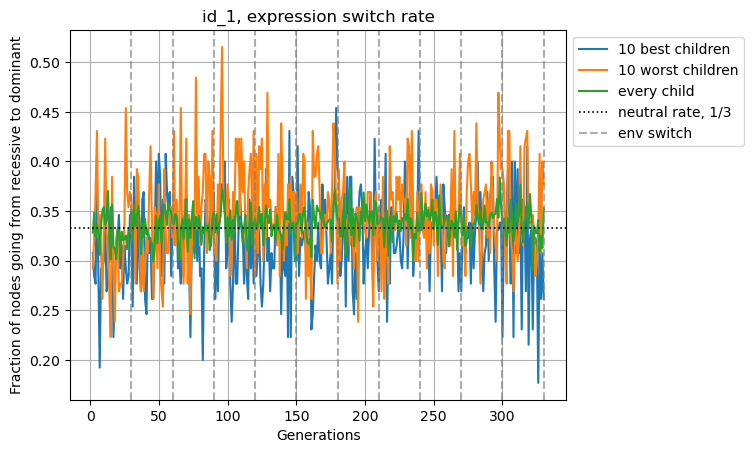

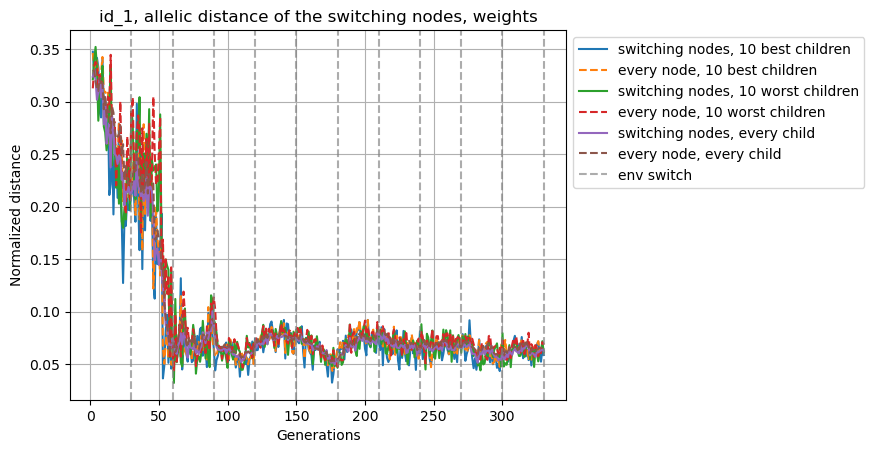

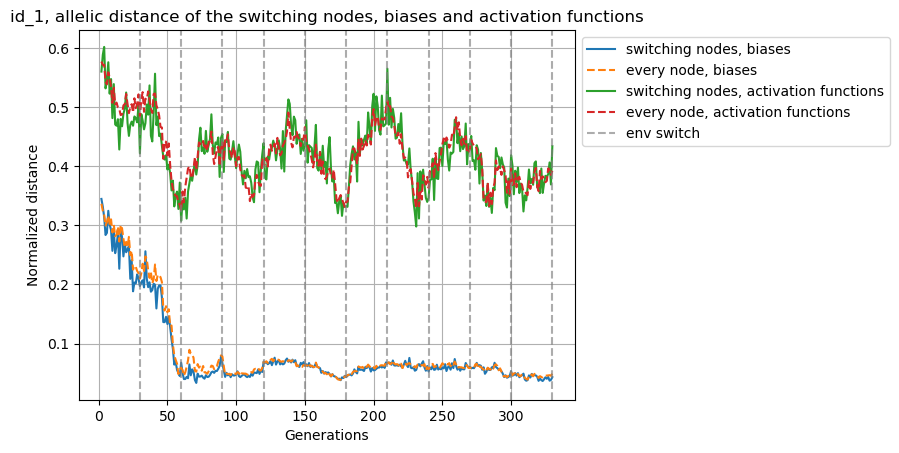

id_2 : 329 generations, 107.8 children per generation, 0 children skipped for a missing parent


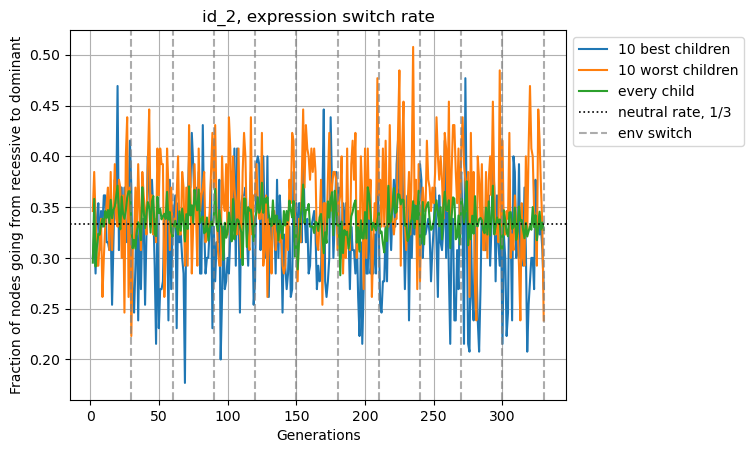

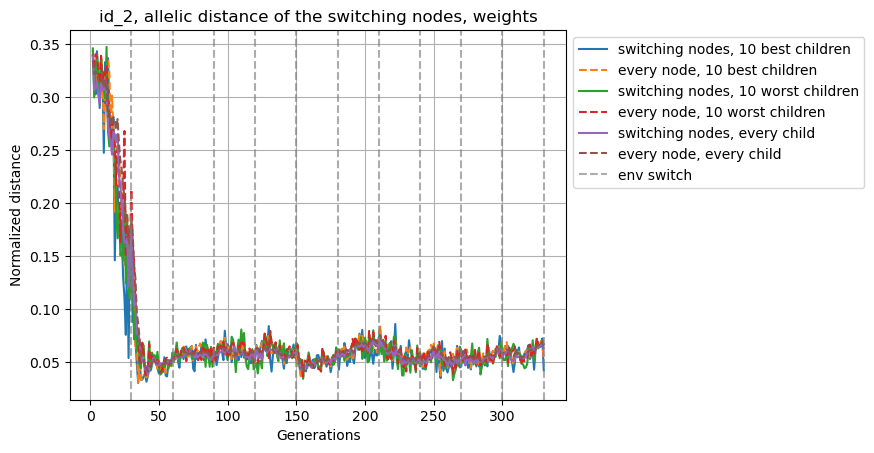

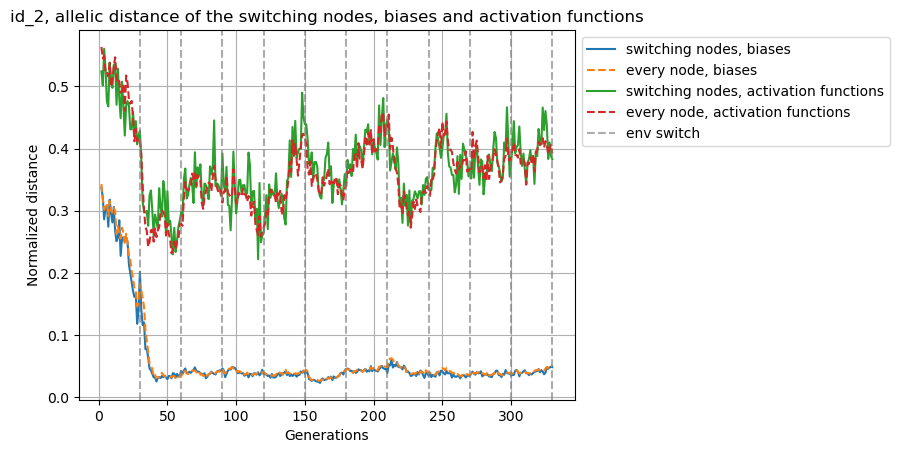

In [23]:
general_generations = []
general_switch_rate = []
general_switched_weight_distance = []
general_all_weight_distance = []
general_switched_bias_distance = []
general_all_bias_distance = []
general_switched_act_distance = []
general_all_act_distance = []


for k in range(diploid_data_config['number_of_config']) :
    general_generations_sigma = []
    general_switch_rate_sigma = []
    general_switched_weight_distance_sigma = []
    general_all_weight_distance_sigma = []
    general_switched_bias_distance_sigma = []
    general_all_bias_distance_sigma = []
    general_switched_act_distance_sigma = []
    general_all_act_distance_sigma = []
    for i in range(diploid_data_config['number_of_exp']) :
        id_exp = number + k * diploid_data_config['number_of_exp'] + i
        results_dir = os.path.join(local_dir, 'results', '{}'.format(path), 'id_{}'.format(id_exp))
        pkl_dir = os.path.join(results_dir, 'diploid', 'pkl')

        # a run of the serie can be absent, or interrupted before the first generation
        if not os.path.isdir(pkl_dir) or not os.path.exists(os.path.join(pkl_dir, '1_genome_registry.pkl')) :
            print('missing run : id_{}'.format(id_exp))
            continue

        generations = []
        switch_rates = [[], [], []]
        switched_weight_distances = [[], [], []]
        all_weight_distances = [[], [], []]
        switched_bias_distances = [[], [], []]
        all_bias_distances = [[], [], []]
        switched_act_distances = [[], [], []]
        all_act_distances = [[], [], []]
        numbers_of_children = []
        numbers_of_missing_parents = []

        # generation 1 is the initial population, it has no parents_registry
        with open(os.path.join(pkl_dir, '1_genome_registry.pkl'), 'rb') as f :
            previous_genomes = dill.load(f)

        first_genome = next(iter(previous_genomes.values()))
        trunk, heads = split_nodes(first_genome.nodes)
        incoming = incoming_by_node(first_genome)

        generation = 2
        while True :

            files = {name : os.path.join(pkl_dir, '{}_{}_registry.pkl'.format(generation, name))
                     for name in ['genome', 'parents', 'fitness', 'age']}

            if not all([os.path.exists(file_dir) for file_dir in files.values()]) :
                break

            loaded = {}
            for name, file_dir in files.items() :
                with open(file_dir, 'rb') as f :
                    loaded[name] = dill.load(f)

            # children of the meiosis : age == 1, and both parents saved at the previous generation
            children = []
            missing = 0
            for key in loaded['genome'].keys() :
                if key not in loaded['age'] or loaded['age'][key].age != 1 :
                    continue
                if key not in loaded['parents'] or key not in loaded['fitness'] :
                    continue
                parents = loaded['parents'][key].parents
                if (generation - 1, parents[0]) not in previous_genomes or (generation - 1, parents[1]) not in previous_genomes :
                    missing += 1
                    continue
                children.append(key)

            children.sort(key = lambda key : loaded['fitness'][key].fitness, reverse = True)

            if not children :
                previous_genomes = loaded['genome']
                generation += 1
                continue

            # the two groups stay disjoint even when the generation has few children
            worst_bound = max(top_n, len(children) - other_n)

            switched_count = [0, 0, 0]
            node_count = [0, 0, 0]
            switched_act = [0.0, 0.0, 0.0]
            switched_weight = [0.0, 0.0, 0.0]
            switched_bias = [0.0, 0.0, 0.0]
            all_act = [0.0, 0.0, 0.0]
            all_weight = [0.0, 0.0, 0.0]
            all_bias = [0.0, 0.0, 0.0]

            for rank, key in enumerate(children) :
                child = loaded['genome'][key]
                child_parents = loaded['parents'][key].parents
                child_choices = loaded['parents'][key].parents_choices

                series = [2]
                if rank < top_n :
                    series.append(0)
                if rank >= worst_bound :
                    series.append(1)

                for node in child.biases[0].keys() :
                    pos = expressed_chrom(child, node)
                    parent_genome = previous_genomes[(generation - 1, child_parents[pos])]
                    index = parental_chrom(node, child_choices[pos], trunk)
                    switched = expressed_chrom(parent_genome, node) != index

                    act, weight, bias = node_distances(child, node, incoming, distance_tool, config)

                    for s in series :
                        node_count[s] += 1
                        all_act[s] += act
                        all_weight[s] += weight
                        all_bias[s] += bias
                        if switched :
                            switched_count[s] += 1
                            switched_act[s] += act
                            switched_weight[s] += weight
                            switched_bias[s] += bias

            for s in range(3) :
                if not node_count[s] :
                    for empty in [switch_rates, all_act_distances, all_weight_distances, all_bias_distances,
                                  switched_act_distances, switched_weight_distances, switched_bias_distances] :
                        empty[s].append(np.nan)
                    continue
                switch_rates[s].append(switched_count[s] / node_count[s])
                all_act_distances[s].append(all_act[s] / node_count[s])
                all_weight_distances[s].append(all_weight[s] / node_count[s])
                all_bias_distances[s].append(all_bias[s] / node_count[s])
                # nan when nothing switched, matplotlib simply skips the point
                switched_act_distances[s].append(switched_act[s] / switched_count[s] if switched_count[s] else np.nan)
                switched_weight_distances[s].append(switched_weight[s] / switched_count[s] if switched_count[s] else np.nan)
                switched_bias_distances[s].append(switched_bias[s] / switched_count[s] if switched_count[s] else np.nan)

            numbers_of_children.append(len(children))
            numbers_of_missing_parents.append(missing)
            generations.append(generation)

            previous_genomes = loaded['genome']
            generation += 1

        print('id_{} : {} generations, {:.1f} children per generation, {} children skipped for a missing parent'.format(
            id_exp, len(generations), np.mean(np.array(numbers_of_children)), int(np.sum(np.array(numbers_of_missing_parents)))))

        # figure A : the switch rate, against the neutral rate
        plt.figure()
        plt.title('id_{}, expression switch rate'.format(id_exp))
        for s in range(3) :
            plt.plot(generations, switch_rates[s], label = labels[s])
        add_neutral_line()
        plt.xlabel('Generations')
        plt.ylabel('Fraction of nodes going from recessive to dominant')
        plt.grid(True, which = 'both')
        add_env_switch_lines(diploid_data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()

        # figure B : how far apart are the two alleles of the nodes that switched
        plt.figure()
        plt.title('id_{}, allelic distance of the switching nodes, weights'.format(id_exp))
        for s in range(3) :
            plt.plot(generations, switched_weight_distances[s], label = 'switching nodes, {}'.format(labels[s]))
            plt.plot(generations, all_weight_distances[s], label = 'every node, {}'.format(labels[s]), linestyle = '--')
        plt.xlabel('Generations')
        plt.ylabel('Normalized distance')
        plt.grid(True, which = 'both')
        add_env_switch_lines(diploid_data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()

        # figure C : same thing for the biases and the activation functions, whole population
        plt.figure()
        plt.title('id_{}, allelic distance of the switching nodes, biases and activation functions'.format(id_exp))
        plt.plot(generations, switched_bias_distances[2], label = 'switching nodes, biases')
        plt.plot(generations, all_bias_distances[2], label = 'every node, biases', linestyle = '--')
        plt.plot(generations, switched_act_distances[2], label = 'switching nodes, activation functions')
        plt.plot(generations, all_act_distances[2], label = 'every node, activation functions', linestyle = '--')
        plt.xlabel('Generations')
        plt.ylabel('Normalized distance')
        plt.grid(True, which = 'both')
        add_env_switch_lines(diploid_data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()

        general_generations_sigma.append(generations)
        general_switch_rate_sigma.append(switch_rates)
        general_switched_weight_distance_sigma.append(switched_weight_distances)
        general_all_weight_distance_sigma.append(all_weight_distances)
        general_switched_bias_distance_sigma.append(switched_bias_distances)
        general_all_bias_distance_sigma.append(all_bias_distances)
        general_switched_act_distance_sigma.append(switched_act_distances)
        general_all_act_distance_sigma.append(all_act_distances)

    general_generations.append(general_generations_sigma)
    general_switch_rate.append(general_switch_rate_sigma)
    general_switched_weight_distance.append(general_switched_weight_distance_sigma)
    general_all_weight_distance.append(general_all_weight_distance_sigma)
    general_switched_bias_distance.append(general_switched_bias_distance_sigma)
    general_all_bias_distance.append(general_all_bias_distance_sigma)
    general_switched_act_distance.append(general_switched_act_distance_sigma)
    general_all_act_distance.append(general_all_act_distance_sigma)

## Mean over every run

The runs are truncated to the shortest one before stacking, and `np.nanmean` is used because a generation
where nothing switched carries a `nan`.

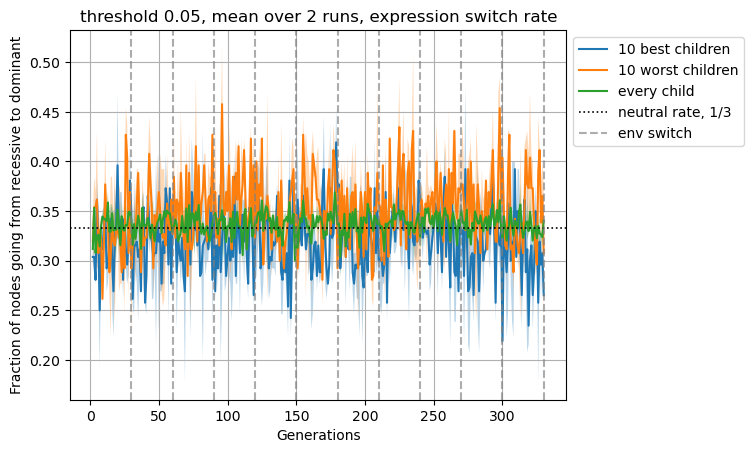

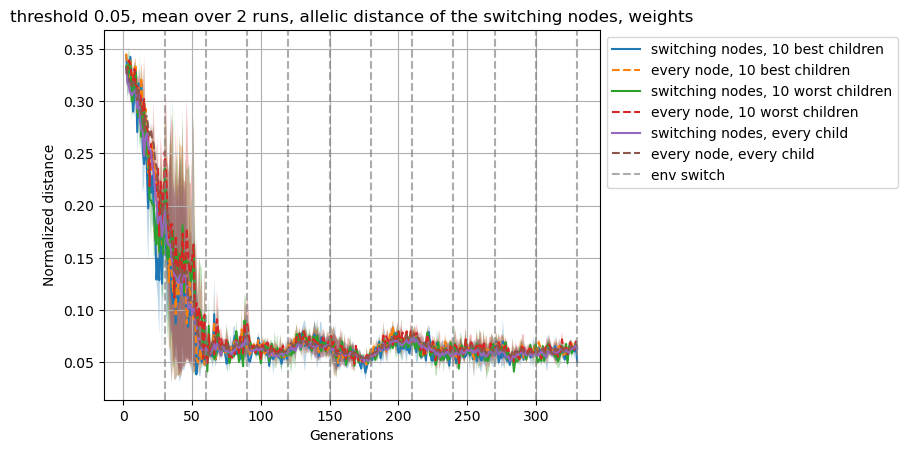

In [24]:
def stack(general, k, series, length) :
    return np.array([run[series][:length] for run in general[k]])


def plot_mean(generations, data, label, linestyle = '-') :
    mean = np.nanmean(data, axis = 0)
    std = np.nanstd(data, axis = 0)
    plt.plot(generations, mean, label = label, linestyle = linestyle)
    plt.fill_between(generations, mean - std, mean + std, alpha = 0.3)


for k in range(diploid_data_config['number_of_config']) :
    threshold = diploid_data_config['threshold_weight'] + k * diploid_data_config['threshold_var']
    length = min([len(generations) for generations in general_generations[k]])
    truncated_generations = general_generations[k][0][:length]
    number_of_runs = len(general_generations[k])

    plt.figure()
    plt.title('threshold {:.2f}, mean over {} runs, expression switch rate'.format(threshold, number_of_runs))
    for s in range(3) :
        plot_mean(truncated_generations, stack(general_switch_rate, k, s, length), labels[s])
    add_neutral_line()
    plt.xlabel('Generations')
    plt.ylabel('Fraction of nodes going from recessive to dominant')
    plt.grid(True, which = 'both')
    add_env_switch_lines(diploid_data_config, truncated_generations)
    plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
    plt.show()

    plt.figure()
    plt.title('threshold {:.2f}, mean over {} runs, allelic distance of the switching nodes, weights'.format(threshold, number_of_runs))
    for s in range(3) :
        plot_mean(truncated_generations, stack(general_switched_weight_distance, k, s, length), 'switching nodes, {}'.format(labels[s]))
        plot_mean(truncated_generations, stack(general_all_weight_distance, k, s, length), 'every node, {}'.format(labels[s]), linestyle = '--')
    plt.xlabel('Generations')
    plt.ylabel('Normalized distance')
    plt.grid(True, which = 'both')
    add_env_switch_lines(diploid_data_config, truncated_generations)
    plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
    plt.show()

## The numbers

The curves are noisy and the effects are small, so the contrast is also printed. A post-switch window is
the 5 generations following a change of environment.

What the reservoir hypothesis predicts is **not** that the best switch more. A switch changes the
expressed phenotype, and when the population is already adapted, changing the phenotype is deleterious on
average : in a stable regime the best children should switch **less**. The signature of the reservoir is a
**reversal of the sign** after a change of environment, negative when stable and positive right after a
switch. Under the null hypothesis the gap is zero in both regimes.

In [25]:
for k in range(diploid_data_config['number_of_config']) :
    length = min([len(generations) for generations in general_generations[k]])
    gens = np.array(general_generations[k][0][:length])
    switch = diploid_data_config['switch']

    post = np.array([1 <= (g % switch) <= 5 for g in gens])
    stable = ~post

    rate = [np.nanmean(stack(general_switch_rate, k, s, length), axis = 0) for s in range(3)]
    switched_distance = [np.nanmean(stack(general_switched_weight_distance, k, s, length), axis = 0) for s in range(3)]
    all_distance = [np.nanmean(stack(general_all_weight_distance, k, s, length), axis = 0) for s in range(3)]

    print('switch every {} generations, {} generations analysed, {} of them post-switch'.format(
        switch, len(gens), int(post.sum())))
    print()
    print('--- expression switch rate, neutral value {:.4f}'.format(neutral_switch_rate))
    print('  {:<22} {:>9} {:>13} {:>9}'.format('', 'overall', 'post-switch', 'stable'))
    for s in range(3) :
        print('  {:<22} {:>9.4f} {:>13.4f} {:>9.4f}'.format(
            labels[s], np.nanmean(rate[s]), np.nanmean(rate[s][post]), np.nanmean(rate[s][stable])))
    print()
    print('  best minus worst :')
    print('    overall     {:+.4f}'.format(np.nanmean(rate[0]) - np.nanmean(rate[1])))
    print('    post-switch {:+.4f}'.format(np.nanmean(rate[0][post]) - np.nanmean(rate[1][post])))
    print('    stable      {:+.4f}'.format(np.nanmean(rate[0][stable]) - np.nanmean(rate[1][stable])))
    print('  -> reservoir signature = negative when stable, positive after a switch')
    print()
    print('--- allelic distance of the weights, switching nodes vs every node')
    print('  {:<22} {:>11} {:>12} {:>8}'.format('', 'switching', 'every node', 'ratio'))
    for s in range(3) :
        print('  {:<22} {:>11.4f} {:>12.4f} {:>8.3f}'.format(
            labels[s], np.nanmean(switched_distance[s]), np.nanmean(all_distance[s]),
            np.nanmean(switched_distance[s]) / np.nanmean(all_distance[s])))
    print('  -> ratio > 1 means the switches happen on the nodes whose two alleles are far apart')
    print()
    print('--- over time, every child')
    for label, lo, hi in [('first 50 gens', 0, 50),
                          ('middle 50', len(gens) // 2 - 25, len(gens) // 2 + 25),
                          ('last 50 gens', len(gens) - 50, len(gens))] :
        print('  {:<15} switch rate {:.4f}   best minus worst {:+.4f}   allelic distance {:.4f}'.format(
            label, np.nanmean(rate[2][lo:hi]),
            np.nanmean(rate[0][lo:hi]) - np.nanmean(rate[1][lo:hi]),
            np.nanmean(all_distance[2][lo:hi])))

switch every 30 generations, 329 generations analysed, 54 of them post-switch

--- expression switch rate, neutral value 0.3333
                           overall   post-switch    stable
  10 best children          0.3208        0.3214    0.3207
  10 worst children         0.3509        0.3532    0.3505
  every child               0.3371        0.3348    0.3376

  best minus worst :
    overall     -0.0301
    post-switch -0.0318
    stable      -0.0297
  -> reservoir signature = negative when stable, positive after a switch

--- allelic distance of the weights, switching nodes vs every node
                           switching   every node    ratio
  10 best children            0.0809       0.0852    0.950
  10 worst children           0.0854       0.0892    0.958
  every child                 0.0834       0.0873    0.955
  -> ratio > 1 means the switches happen on the nodes whose two alleles are far apart

--- over time, every child
  first 50 gens   switch rate 0.3346   best minus w

## Sanity check

The one test that matters : reconstruct the parental allele of every child of one generation and compare
it to what the child actually carries. The only difference between the two is the mutation, which happens
after the meiosis, so the match has to be about `1 - threshold`. The inverted hypothesis, trunk and heads
swapped, has to be near 0.

It is run on the **weights** and on the **dominances**. The dominances are the ones that matter : they are
what decides the expression, so they are what the whole notebook rests on. They are recombined by the same
block of `meiosis_crossover` (genome_operator.py:647-655), but checking the weights only would leave that
as an assumption rather than a verification.

If the two columns are close to each other, the reconstruction is wrong and every curve above is
meaningless.

The last test cross-checks the two ways of spotting an elite : `age == 1` and `parents != [id, id]` have
to select exactly the same children.

In [26]:
check_generation = 3
pkl_dir = os.path.join(local_dir, 'results', '{}'.format(path), 'id_{}'.format(number), 'diploid', 'pkl')

loaded = {}
for name in ['genome', 'parents', 'age'] :
    with open(os.path.join(pkl_dir, '{}_{}_registry.pkl'.format(check_generation, name)), 'rb') as f :
        loaded[name] = dill.load(f)
with open(os.path.join(pkl_dir, '{}_genome_registry.pkl'.format(check_generation - 1)), 'rb') as f :
    check_previous_genomes = dill.load(f)

trunk, heads = split_nodes(next(iter(loaded['genome'].values())).nodes)
print('trunk : {}'.format(trunk))
print('heads : {}'.format(heads))
print()

by_age = set()
by_parents = set()
for (g, entity_id) in loaded['genome'].keys() :
    if (g, entity_id) in loaded['age'] and loaded['age'][(g, entity_id)].age == 1 :
        by_age.add(entity_id)
    if (g, entity_id) in loaded['parents'] :
        parents = loaded['parents'][(g, entity_id)].parents
        if not (parents[0] == entity_id and parents[1] == entity_id) :
            by_parents.add(entity_id)

print('generation {} : {} individuals saved'.format(check_generation, len(loaded['genome'])))
print('  age == 1            : {}'.format(len(by_age)))
print('  parents != [id, id] : {}'.format(len(by_parents)))
print('  identical sets      : {}'.format(by_age == by_parents))
print()

weight_matches = [0, 0]
dominance_matches = [0, 0]
weight_total = 0
dominance_total = 0

for (g, entity_id) in loaded['genome'].keys() :
    if entity_id not in by_age or (g, entity_id) not in loaded['parents'] :
        continue
    parents = loaded['parents'][(g, entity_id)].parents
    choices = loaded['parents'][(g, entity_id)].parents_choices
    if (g - 1, parents[0]) not in check_previous_genomes or (g - 1, parents[1]) not in check_previous_genomes :
        continue
    child = loaded['genome'][(g, entity_id)]

    for pos in range(2) :
        parent_genome = check_previous_genomes[(g - 1, parents[pos])]

        for (previous_node, node) in child.connections[pos].keys() :
            index = parental_chrom(node, choices[pos], trunk)
            value = child.connections[pos][(previous_node, node)]
            weight_matches[0] += value == parent_genome.connections[index][(previous_node, node)]
            weight_matches[1] += value == parent_genome.connections[1 - index][(previous_node, node)]
            weight_total += 1

        for node in child.dominances[pos].keys() :
            index = parental_chrom(node, choices[pos], trunk)
            value = child.dominances[pos][node]
            dominance_matches[0] += value == parent_genome.dominances[index][node]
            dominance_matches[1] += value == parent_genome.dominances[1 - index][node]
            dominance_total += 1

print('values identical bit for bit to the reconstructed parental allele :')
print('  {:<12} {:>10} {:>12} {:>12}'.format('', 'hypothesis', 'inverted', 'expected'))
print('  {:<12} {:>10.4f} {:>12.4f} {:>12.2f}'.format(
    'weights', weight_matches[0] / weight_total, weight_matches[1] / weight_total,
    1 - diploid_data_config['threshold_weight']))
print('  {:<12} {:>10.4f} {:>12.4f} {:>12.2f}'.format(
    'dominances', dominance_matches[0] / dominance_total, dominance_matches[1] / dominance_total,
    1 - diploid_data_config['threshold_dominance']))
print()
print('on {} weights and {} dominances'.format(weight_total, dominance_total))

trunk : [11, 12, 13, 14, 15]
heads : [16, 17, 18, 19, 20, 21, 22, 23]

generation 3 : 77 individuals saved
  age == 1            : 75
  parents != [id, id] : 75
  identical sets      : True

values identical bit for bit to the reconstructed parental allele :
               hypothesis     inverted     expected
  weights          0.9522       0.0056         0.95
  dominances       0.9395       0.0046         0.93

on 13650 weights and 1950 dominances
